# 1. Data Loading and Initial Exploration
---

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

import xml.etree.ElementTree as ET
import csv

xml_file_path = '/kaggle/input/datasets/bhadramohit/india-air-quality-index2024-dataset/data_aqi_cpcb.xml'
csv_file_path = 'IndiaAQIcsv'

tree = ET.parse(xml_file_path)
root = tree.getroot()


with open(csv_file_path, 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    
    header = [
        "Country", "State", "City", "Station", "Latitude", "Longitude", "Last Update",
        "Pollutant", "Min", "Max", "Avg", "AQI", "Predominant Parameter"
    ]
    writer.writerow(header)

    
    for country in root.findall('Country'):
        country_id = country.get('id')
        for state in country.findall('State'):
            state_id = state.get('id')
            for city in state.findall('City'):
                city_id = city.get('id')
                for station in city.findall('Station'):
                    station_id = station.get('id')
                    latitude = station.get('latitude')
                    longitude = station.get('longitude')
                    last_update = station.get('lastupdate')
                    
                   
                    for pollutant in station.findall('Pollutant_Index'):
                        pollutant_id = pollutant.get('id')
                        min_val = pollutant.get('Min')
                        max_val = pollutant.get('Max')
                        avg_val = pollutant.get('Avg')
                        
                        
                        aqi_value = ""
                        predominant_param = ""
                        
                        
                        aqi = station.find('Air_Quality_Index')
                        if aqi is not None:
                            aqi_value = aqi.get('Value')
                            predominant_param = aqi.get('Predominant_Parameter')
                        
                        
                        writer.writerow([
                            country_id, state_id, city_id, station_id, latitude, longitude,
                            last_update, pollutant_id, min_val, max_val, avg_val,
                            aqi_value, predominant_param
                        ])

print("="*80)
print("BASF SE - Air Quality Index Prediction System")
print("Environmental Monitoring & Emission Control Solution")
print("="*80)

print("\n[1] Loading Dataset...")
df = pd.read_csv('IndiaAQIcsv')

print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nData Types:")
print(df.dtypes)

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nBasic Statistics:")
print(df.describe())

BASF SE - Air Quality Index Prediction System
Environmental Monitoring & Emission Control Solution

[1] Loading Dataset...

Dataset Shape: (3285, 13)
Columns: ['Country', 'State', 'City', 'Station', 'Latitude', 'Longitude', 'Last Update', 'Pollutant', 'Min', 'Max', 'Avg', 'AQI', 'Predominant Parameter']

First few rows:
  Country           State       City                         Station  \
0   India  Andhra_Pradesh  Amaravati  Secretariat, Amaravati - APPCB   
1   India  Andhra_Pradesh  Amaravati  Secretariat, Amaravati - APPCB   
2   India  Andhra_Pradesh  Amaravati  Secretariat, Amaravati - APPCB   
3   India  Andhra_Pradesh  Amaravati  Secretariat, Amaravati - APPCB   
4   India  Andhra_Pradesh  Amaravati  Secretariat, Amaravati - APPCB   

    Latitude  Longitude          Last Update Pollutant  Min  Max  Avg  AQI  \
0  16.515083  80.518167  20-11-2023 12:00:00     PM2.5  NaN  NaN  NaN  NaN   
1  16.515083  80.518167  20-11-2023 12:00:00      PM10  NaN  NaN  NaN  NaN   
2  16.51508

# 2. Data Cleaning and Pre-Processing
---

In [15]:
print("\n" + "="*80)
print("[2] Data Preprocessing...")
print("="*80)

# Convert numeric columns
numeric_cols = ['Min', 'Max', 'Avg', 'AQI', 'Latitude', 'Longitude']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle datetime
df['Last Update'] = pd.to_datetime(df['Last Update'], errors='coerce')

# Extract temporal features
df['Hour'] = df['Last Update'].dt.hour
df['Day'] = df['Last Update'].dt.day
df['Month'] = df['Last Update'].dt.month
df['DayOfWeek'] = df['Last Update'].dt.dayofweek
df['Year'] = df['Last Update'].dt.year

# Pivot pollutant data to get features for each pollutant
print("\n[3] Restructuring Pollutant Data...")
pollutant_features = df.pivot_table(
    index=['Country', 'State', 'City', 'Station', 'Latitude', 'Longitude', 
           'Last Update', 'AQI', 'Predominant Parameter', 'Hour', 'Day', 
           'Month', 'DayOfWeek', 'Year'],
    columns='Pollutant',
    values=['Min', 'Max', 'Avg'],
    aggfunc='first'
).reset_index()

# Flatten column names
pollutant_features.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                               for col in pollutant_features.columns.values]

print(f"\nRestructured Dataset Shape: {pollutant_features.shape}")
print(f"Columns: {pollutant_features.columns.tolist()}")



[2] Data Preprocessing...

[3] Restructuring Pollutant Data...

Restructured Dataset Shape: (454, 35)
Columns: ['Country', 'State', 'City', 'Station', 'Latitude', 'Longitude', 'Last Update', 'AQI', 'Predominant Parameter', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Year', 'Avg_CO', 'Avg_NH3', 'Avg_NO2', 'Avg_OZONE', 'Avg_PM10', 'Avg_PM2.5', 'Avg_SO2', 'Max_CO', 'Max_NH3', 'Max_NO2', 'Max_OZONE', 'Max_PM10', 'Max_PM2.5', 'Max_SO2', 'Min_CO', 'Min_NH3', 'Min_NO2', 'Min_OZONE', 'Min_PM10', 'Min_PM2.5', 'Min_SO2']


# 3. Feature Engineering
---

In [16]:
print("\n" + "="*80)
print("[4] Feature Engineering...")
print("="*80)

df_model = pollutant_features.copy()

# Remove rows where AQI is missing (target variable)
df_model = df_model[df_model['AQI'].notna()]
print(f"\nDataset after removing missing AQI: {df_model.shape}")

# Encode categorical variables
le_state = LabelEncoder()
le_city = LabelEncoder()
le_predominant = LabelEncoder()

df_model['State_Encoded'] = le_state.fit_transform(df_model['State'].astype(str))
df_model['City_Encoded'] = le_city.fit_transform(df_model['City'].astype(str))
df_model['Predominant_Encoded'] = le_predominant.fit_transform(
    df_model['Predominant Parameter'].astype(str)
)

# Create additional features
# Pollutant concentration variations
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
for pollutant in pollutants:
    avg_col = f'Avg_{pollutant}'
    min_col = f'Min_{pollutant}'
    max_col = f'Max_{pollutant}'
    
    if avg_col in df_model.columns and min_col in df_model.columns:
        df_model[f'{pollutant}_Range'] = df_model[max_col] - df_model[min_col]

# Select features for modeling
feature_cols = []

# Geographic features
feature_cols.extend(['Latitude', 'Longitude', 'State_Encoded', 'City_Encoded'])

# Temporal features
feature_cols.extend(['Hour', 'Day', 'Month', 'DayOfWeek'])

# Pollutant features
for pollutant in pollutants:
    for stat in ['Avg', 'Min', 'Max']:
        col = f'{stat}_{pollutant}'
        if col in df_model.columns:
            feature_cols.append(col)
    
    range_col = f'{pollutant}_Range'
    if range_col in df_model.columns:
        feature_cols.append(range_col)

# Predominant parameter
feature_cols.append('Predominant_Encoded')

# Prepare X and y
X = df_model[feature_cols].copy()
y = df_model['AQI'].copy()

print(f"\nFeatures selected: {len(feature_cols)}")
print(f"Feature names: {feature_cols}")

# Handle missing values
print("\n[5] Handling Missing Values...")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"Missing values after imputation: {X_imputed.isnull().sum().sum()}")


[4] Feature Engineering...

Dataset after removing missing AQI: (454, 35)

Features selected: 29
Feature names: ['Latitude', 'Longitude', 'State_Encoded', 'City_Encoded', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Avg_PM2.5', 'Min_PM2.5', 'Max_PM2.5', 'PM2.5_Range', 'Avg_PM10', 'Min_PM10', 'Max_PM10', 'PM10_Range', 'Avg_NO2', 'Min_NO2', 'Max_NO2', 'NO2_Range', 'Avg_SO2', 'Min_SO2', 'Max_SO2', 'SO2_Range', 'Avg_CO', 'Min_CO', 'Max_CO', 'CO_Range', 'Predominant_Encoded']

[5] Handling Missing Values...
Missing values after imputation: 0


# 4. Model Training
---

In [17]:
print("\n" + "="*80)
print("[6] Splitting Dataset...")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*80)
print("[7] Training Multiple Regression Models...")
print("="*80)

models = {
    # Linear Models
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
#    'Lasso Regression': Lasso(alpha=1.0),
#    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42),
#    'Bayesian Ridge': BayesianRidge(),
    
    # Tree-Based Models
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
#    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    
    # Boosting Models
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
#    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    
    # Other Models
#    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
#    'Support Vector Regressor': SVR(kernel='rbf', C=1.0),
#    'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True)
}

results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")
    
    try:
        # Train model
        if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 
                    'ElasticNet', 'Bayesian Ridge', 'Support Vector Regressor', 'Neural Network']:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        
        # Evaluate
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name] = {
            'model': model,
            'predictions': y_pred,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        }
        
        print(f"MSE: {mse:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"MAE: {mae:.2f}")
        print(f"R² Score: {r2:.4f}")
    
    except Exception as e:
        print(f"Error training {name}: {str(e)}")
        continue


[6] Splitting Dataset...
Training set size: (363, 29)
Test set size: (91, 29)

[7] Training Multiple Regression Models...

--- Linear Regression ---
MSE: 153.74
RMSE: 12.40
MAE: 8.99
R² Score: 0.9839

--- Ridge Regression ---
MSE: 140.30
RMSE: 11.84
MAE: 8.87
R² Score: 0.9853

--- Decision Tree ---
MSE: 166.13
RMSE: 12.89
MAE: 7.43
R² Score: 0.9826

--- Random Forest ---
MSE: 102.47
RMSE: 10.12
MAE: 5.58
R² Score: 0.9893

--- Gradient Boosting ---
MSE: 92.74
RMSE: 9.63
MAE: 6.26
R² Score: 0.9903

--- XGBoost ---
MSE: 95.90
RMSE: 9.79
MAE: 6.02
R² Score: 0.9900


# 5. Model comparison
---

In [18]:
print("\n" + "="*80)
print("[8] Model Comparison Summary")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE': [results[m]['RMSE'] for m in results],
    'MAE': [results[m]['MAE'] for m in results],
    'R² Score': [results[m]['R2'] for m in results]
})

print("\n", comparison_df.to_string(index=False))

best_model_name = comparison_df.loc[comparison_df['R² Score'].idxmax(), 'Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   R² Score: {results[best_model_name]['R2']:.4f}")
print(f"   RMSE: {results[best_model_name]['RMSE']:.2f}")


[8] Model Comparison Summary

             Model      RMSE      MAE  R² Score
Linear Regression 12.399095 8.994107  0.983904
 Ridge Regression 11.844657 8.867247  0.985311
    Decision Tree 12.889198 7.430421  0.982606
    Random Forest 10.122603 5.583187  0.989272
Gradient Boosting  9.629910 6.259983  0.990291
          XGBoost  9.793016 6.018888  0.989959

🏆 Best Model: Gradient Boosting
   R² Score: 0.9903
   RMSE: 9.63


# 6. Feature importance

---

In [19]:
print("\n" + "="*80)
print("[9] Feature Importance Analysis")
print("="*80)

if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nImportance of Features:")
    print(feature_importance.head(100).to_string(index=False))


[9] Feature Importance Analysis

Importance of Features:
            Feature  Importance
          Avg_PM2.5    0.892386
           Avg_PM10    0.096041
           Max_PM10    0.001834
           CO_Range    0.001148
           Latitude    0.001122
          Max_PM2.5    0.001089
             Max_CO    0.001019
Predominant_Encoded    0.000692
          Min_PM2.5    0.000532
             Avg_CO    0.000463
            Avg_NO2    0.000421
           Min_PM10    0.000336
            Min_NO2    0.000331
            Avg_SO2    0.000304
            Min_SO2    0.000260
          Longitude    0.000256
        PM2.5_Range    0.000252
            Max_NO2    0.000238
          NO2_Range    0.000232
         PM10_Range    0.000226
             Min_CO    0.000217
            Max_SO2    0.000210
       City_Encoded    0.000144
          SO2_Range    0.000141
      State_Encoded    0.000107
              Month    0.000000
                Day    0.000000
          DayOfWeek    0.000000
              

# 7. Data Visualization
---


[10] Generating Visualizations...

✓ Visualizations saved as 'aqi_prediction_analysis.png'

[11] Creating Prediction Function...

Example Prediction:
Predicted AQI: 87.70
Actual AQI: 87.00
Error: 0.70


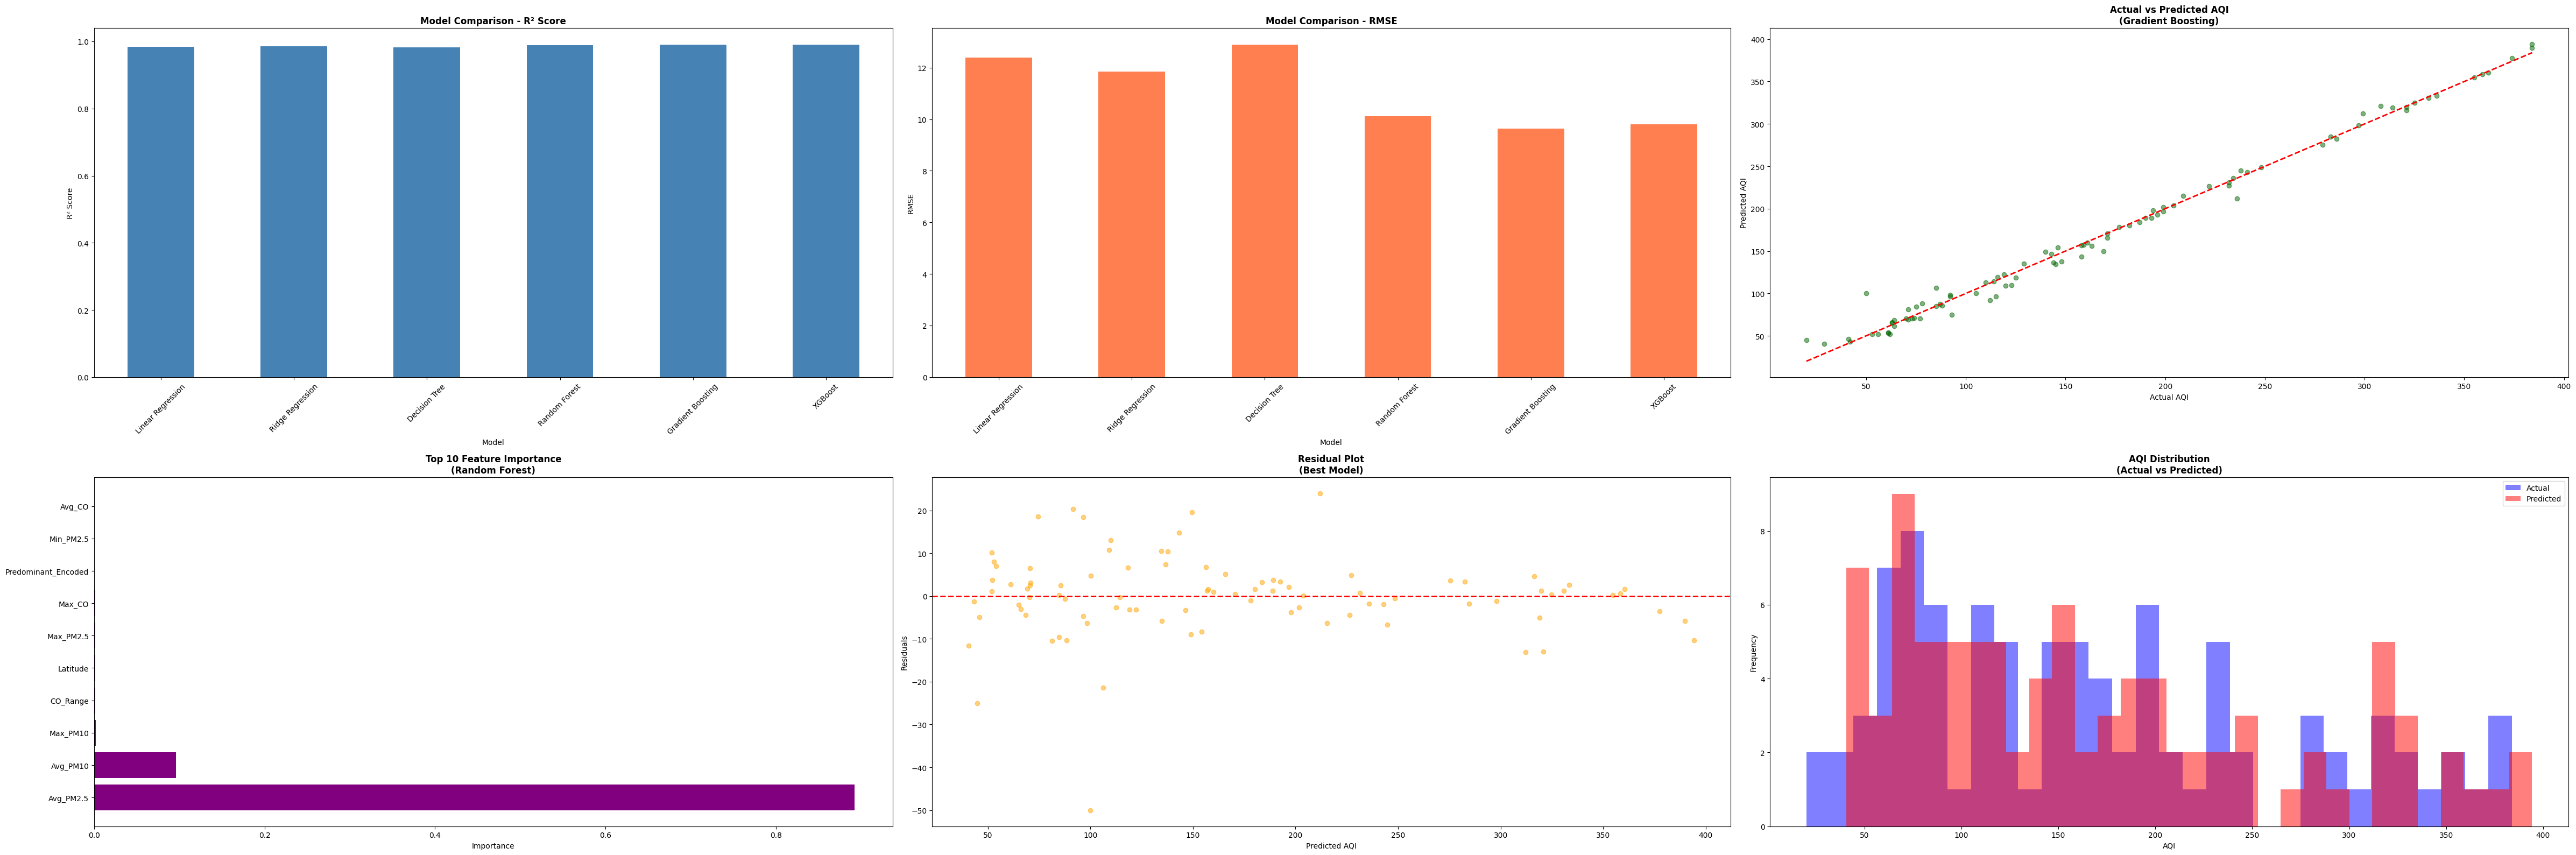

In [20]:
print("\n" + "="*80)
print("[10] Generating Visualizations...")
print("="*80)

# Create figure with subplots
fig = plt.figure(figsize=(48, 16))

# 1. Model Comparison
ax1 = plt.subplot(2, 3, 1)
comparison_df.plot(x='Model', y='R² Score', kind='bar', ax=ax1, legend=False, color='steelblue')
ax1.set_title('Model Comparison - R² Score', fontsize=12, fontweight='bold')
ax1.set_xlabel('Model')
ax1.set_ylabel('R² Score')
ax1.tick_params(axis='x', rotation=45)

# 2. RMSE Comparison
ax2 = plt.subplot(2, 3, 2)
comparison_df.plot(x='Model', y='RMSE', kind='bar', ax=ax2, legend=False, color='coral')
ax2.set_title('Model Comparison - RMSE', fontsize=12, fontweight='bold')
ax2.set_xlabel('Model')
ax2.set_ylabel('RMSE')
ax2.tick_params(axis='x', rotation=45)

# 3. Actual vs Predicted (Best Model)
ax3 = plt.subplot(2, 3, 3)
y_pred_best = results[best_model_name]['predictions']
ax3.scatter(y_test, y_pred_best, alpha=0.5, color='darkgreen')
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax3.set_title(f'Actual vs Predicted AQI\n({best_model_name})', fontsize=12, fontweight='bold')
ax3.set_xlabel('Actual AQI')
ax3.set_ylabel('Predicted AQI')

# 4. Feature Importance
ax4 = plt.subplot(2, 3, 4)
if 'Random Forest' in results:
    top_features = feature_importance.head(10)
    ax4.barh(top_features['Feature'], top_features['Importance'], color='purple')
    ax4.set_title('Top 10 Feature Importance\n(Random Forest)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Importance')

# 5. Residual Plot
ax5 = plt.subplot(2, 3, 5)
residuals = y_test - y_pred_best
ax5.scatter(y_pred_best, residuals, alpha=0.5, color='orange')
ax5.axhline(y=0, color='r', linestyle='--', lw=2)
ax5.set_title('Residual Plot\n(Best Model)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Predicted AQI')
ax5.set_ylabel('Residuals')

# 6. AQI Distribution
ax6 = plt.subplot(2, 3, 6)
ax6.hist(y_test, bins=30, alpha=0.5, label='Actual', color='blue')
ax6.hist(y_pred_best, bins=30, alpha=0.5, label='Predicted', color='red')
ax6.set_title('AQI Distribution\n(Actual vs Predicted)', fontsize=12, fontweight='bold')
ax6.set_xlabel('AQI')
ax6.set_ylabel('Frequency')
ax6.legend()

plt.tight_layout()
plt.savefig('aqi_prediction_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualizations saved as 'aqi_prediction_analysis.png'")

# ============================================================================
# STEP 11: PREDICTION FUNCTION
# ============================================================================
print("\n" + "="*80)
print("[11] Creating Prediction Function...")
print("="*80)

def predict_aqi(input_data, model=results[best_model_name]['model'], 
                use_scaling=best_model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']):
    """
    Predict AQI for new data
    
    Parameters:
    input_data: dict or DataFrame with feature values
    
    Returns:
    predicted AQI value
    """
    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    else:
        input_df = input_data
    
    # Ensure all features are present
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0
    
    input_df = input_df[feature_cols]
    
    # Handle missing values
    input_imputed = pd.DataFrame(
        imputer.transform(input_df),
        columns=input_df.columns
    )
    
    if use_scaling:
        input_scaled = scaler.transform(input_imputed)
        prediction = model.predict(input_scaled)
    else:
        prediction = model.predict(input_imputed)
    
    return prediction[0]

# Example prediction
print("\nExample Prediction:")
sample_data = X_test.iloc[0].to_dict()
predicted_aqi = predict_aqi(sample_data)
actual_aqi = y_test.iloc[0]
print(f"Predicted AQI: {predicted_aqi:.2f}")
print(f"Actual AQI: {actual_aqi:.2f}")
print(f"Error: {abs(predicted_aqi - actual_aqi):.2f}")


print("\n" + "="*80)
print("[12] Generating Model Comparison Heatmap...")
print("="*80)

# Create comparison matrix
metrics_matrix = pd.DataFrame({
    'Model': list(results.keys()),
    'R² Score': [results[model]['R2'] for model in results],
    'RMSE': [results[model]['RMSE'] for model in results],
    'MAE': [results[model]['MAE'] for model in results],
    'MSE': [results[model]['MSE'] for model in results]
})

# Normalize metrics for better visualization (0-1 scale)
metrics_for_heatmap = metrics_matrix.copy()
metrics_for_heatmap.set_index('Model', inplace=True)

# For R² Score, higher is better (keep as is, normalized)
metrics_for_heatmap['R² Score (Normalized)'] = (
    metrics_for_heatmap['R² Score'] - metrics_for_heatmap['R² Score'].min()
) / (metrics_for_heatmap['R² Score'].max() - metrics_for_heatmap['R² Score'].min())

# For error metrics (RMSE, MAE, MSE), lower is better (invert)
for metric in ['RMSE', 'MAE', 'MSE']:
    metrics_for_heatmap[f'{metric} (Inverted)'] = 1 - (
        (metrics_for_heatmap[metric] - metrics_for_heatmap[metric].min()) / 
        (metrics_for_heatmap[metric].max() - metrics_for_heatmap[metric].min())
    )

# Select normalized columns for heatmap
heatmap_data = metrics_for_heatmap[['R² Score (Normalized)', 'RMSE (Inverted)', 
                                      'MAE (Inverted)', 'MSE (Inverted)']]
heatmap_data.columns = ['R² Score', 'RMSE', 'MAE', 'MSE']

# Create heatmap
plt.figure(figsize=(22, 10))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.3f', 
            cmap='RdYlGn',
            cbar_kws={'label': 'Performance Score (Higher is Better)'},
            linewidths=1,
            linecolor='gray',
            vmin=0,
            vmax=1)

plt.title('Model Performance Comparison Heatmap\n(All Metrics Normalized: Higher = Better)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Evaluation Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Models', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('aqi_model_comparison_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✓ Model comparison heatmap saved as 'aqi_model_comparison_heatmap.png'")



In [21]:
print("\n" + "="*80)
print("[8.5] Model Accuracy Analysis")
print("="*80)

# Calculate accuracy metrics for each model
accuracy_results = []

for name, result in results.items():
    y_pred = result['predictions']
    
    # Calculate percentage-based accuracy metrics
    # Method 1: Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    # Method 2: Accuracy within tolerance ranges
    tolerance_5 = np.mean(np.abs(y_test - y_pred) <= 5) * 100  # Within 5 AQI points
    tolerance_10 = np.mean(np.abs(y_test - y_pred) <= 10) * 100  # Within 10 AQI points
    tolerance_20 = np.mean(np.abs(y_test - y_pred) <= 20) * 100  # Within 20 AQI points
    
    # Method 3: Accuracy Score (R² converted to percentage)
    accuracy_r2 = max(0, result['R2']) * 100  # R² as percentage (0-100%)
    
    # Method 4: Prediction accuracy (1 - normalized RMSE)
    max_aqi = y_test.max()
    min_aqi = y_test.min()
    normalized_rmse = result['RMSE'] / (max_aqi - min_aqi)
    prediction_accuracy = max(0, (1 - normalized_rmse) * 100)
    
    accuracy_results.append({
        'Model': name,
        'R² Accuracy (%)': accuracy_r2,
        'Prediction Accuracy (%)': prediction_accuracy,
        'MAPE (%)': mape,
        'Within ±5 AQI (%)': tolerance_5,
        'Within ±10 AQI (%)': tolerance_10,
        'Within ±20 AQI (%)': tolerance_20
    })

accuracy_df = pd.DataFrame(accuracy_results).sort_values('Prediction Accuracy (%)', ascending=False)

print("\n📊 DETAILED ACCURACY METRICS:")
print("="*80)
print(accuracy_df.to_string(index=False))

print("\n" + "="*80)
print("ACCURACY INTERPRETATION GUIDE:")
print("="*80)
print("• R² Accuracy: Percentage of variance explained (higher = better)")
print("• Prediction Accuracy: Overall prediction quality (0-100%, higher = better)")
print("• MAPE: Mean Absolute Percentage Error (lower = better)")
print("• Within ±X AQI: Percentage of predictions within X points of actual (higher = better)")

# Best model accuracy summary
best_accuracy_model = accuracy_df.iloc[0]
print("\n" + "="*80)
print(f"🎯 BEST MODEL ACCURACY: {best_accuracy_model['Model']}")
print("="*80)
print(f"   R² Accuracy:          {best_accuracy_model['R² Accuracy (%)']:.2f}%")
print(f"   Prediction Accuracy:  {best_accuracy_model['Prediction Accuracy (%)']:.2f}%")
print(f"   MAPE:                 {best_accuracy_model['MAPE (%)']:.2f}%")
print(f"   Within ±5 AQI:        {best_accuracy_model['Within ±5 AQI (%)']:.2f}%")
print(f"   Within ±10 AQI:       {best_accuracy_model['Within ±10 AQI (%)']:.2f}%")
print(f"   Within ±20 AQI:       {best_accuracy_model['Within ±20 AQI (%)']:.2f}%")

# Performance category
if best_accuracy_model['Prediction Accuracy (%)'] >= 90:
    category = "EXCELLENT ⭐⭐⭐⭐⭐"
elif best_accuracy_model['Prediction Accuracy (%)'] >= 80:
    category = "VERY GOOD ⭐⭐⭐⭐"
elif best_accuracy_model['Prediction Accuracy (%)'] >= 70:
    category = "GOOD ⭐⭐⭐"
elif best_accuracy_model['Prediction Accuracy (%)'] >= 60:
    category = "FAIR ⭐⭐"
else:
    category = "NEEDS IMPROVEMENT ⭐"

print(f"\n   Performance Rating:   {category}")



[8.5] Model Accuracy Analysis

📊 DETAILED ACCURACY METRICS:
            Model  R² Accuracy (%)  Prediction Accuracy (%)  MAPE (%)  Within ±5 AQI (%)  Within ±10 AQI (%)  Within ±20 AQI (%)
Gradient Boosting        99.029057                97.354420  7.332714          60.439560           78.021978           94.505495
          XGBoost        98.995888                97.309611  6.951523          61.538462           81.318681           94.505495
    Random Forest        98.927163                97.219065  6.742638          69.230769           86.813187           96.703297
 Ridge Regression        98.531093                96.745973  8.203341          36.263736           69.230769           91.208791
Linear Regression        98.390358                96.593655  8.319794          32.967033           69.230769           92.307692
    Decision Tree        98.260594                96.459012  9.471300          60.439560           80.219780           93.406593

ACCURACY INTERPRETATION GUIDE:
• R²

# 8. Prediction Function
---

In [22]:
print("\n" + "="*80)
print("[11] Creating Prediction Function...")
print("="*80)

def predict_aqi(input_data, model=results[best_model_name]['model'], 
                use_scaling=best_model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']):
    """
    Predict AQI for new data
    
    Parameters:
    input_data: dict or DataFrame with feature values
    
    Returns:
    predicted AQI value
    """
    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    else:
        input_df = input_data
    
    # Ensure all features are present
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0
    
    input_df = input_df[feature_cols]
    
    # Handle missing values
    input_imputed = pd.DataFrame(
        imputer.transform(input_df),
        columns=input_df.columns
    )
    
    if use_scaling:
        input_scaled = scaler.transform(input_imputed)
        prediction = model.predict(input_scaled)
    else:
        prediction = model.predict(input_imputed)
    
    return prediction[0]

# Example prediction
print("\nExample Prediction:")
sample_data = X_test.iloc[0].to_dict()
predicted_aqi = predict_aqi(sample_data)
actual_aqi = y_test.iloc[0]
print(f"Predicted AQI: {predicted_aqi:.2f}")
print(f"Actual AQI: {actual_aqi:.2f}")
print(f"Error: {abs(predicted_aqi - actual_aqi):.2f}")

print("\n" + "="*80)
print("[12] Saving Model and Preprocessors...")
print("="*80)

import pickle

# Save best model
with open('best_aqi_model.pkl', 'wb') as f:
    pickle.dump(results[best_model_name]['model'], f)

# Save preprocessors
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

# Save feature columns
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("\n✓ Model saved as 'best_aqi_model.pkl'")
print("✓ Scaler saved as 'scaler.pkl'")
print("✓ Imputer saved as 'imputer.pkl'")
print("✓ Feature columns saved as 'feature_cols.pkl'")


[11] Creating Prediction Function...

Example Prediction:
Predicted AQI: 87.70
Actual AQI: 87.00
Error: 0.70

[12] Saving Model and Preprocessors...

✓ Model saved as 'best_aqi_model.pkl'
✓ Scaler saved as 'scaler.pkl'
✓ Imputer saved as 'imputer.pkl'
✓ Feature columns saved as 'feature_cols.pkl'


# 9. Summary
---

In [23]:
print("\n" + "="*80)
print("FINAL SUMMARY - BASF SE AQI PREDICTION SYSTEM")
print("="*80)
print(f"\n✓ Total Records Processed: {len(df_model)}")
print(f"✓ Features Used: {len(feature_cols)}")
print(f"✓ Best Model: {best_model_name}")
print(f"✓ Model Performance:")
print(f"  - R² Score: {results[best_model_name]['R2']:.4f}")
print(f"  - RMSE: {results[best_model_name]['RMSE']:.2f}")
print(f"  - MAE: {results[best_model_name]['MAE']:.2f}")
print(f"\n✓ Model ready for deployment in environmental monitoring systems")
print(f"✓ Can assist regulatory bodies in proactive emission control")
print("="*80)


FINAL SUMMARY - BASF SE AQI PREDICTION SYSTEM

✓ Total Records Processed: 454
✓ Features Used: 29
✓ Best Model: Gradient Boosting
✓ Model Performance:
  - R² Score: 0.9903
  - RMSE: 9.63
  - MAE: 6.26

✓ Model ready for deployment in environmental monitoring systems
✓ Can assist regulatory bodies in proactive emission control
